# `KroneckerSum` vs `SumKronecker` — two operators, one confusing name

Two of the most useful structured operators in `gaussx` have nearly identical names — and very different jobs. Sorting them out is worth a notebook of its own.

| Operator | Definition | Where it appears |
|---|---|---|
| `KroneckerSum` $A\oplus B$ | $A\otimes I_b + I_a\otimes B$ | separable PDEs, spacetime GMRF priors, additive Gaussian fields |
| `SumKronecker` | $A_1\otimes B_1 + A_2\otimes B_2$ | multi-output GPs with correlated tasks, signal + iid noise on a grid |

Both produce $n_a n_b \times n_a n_b$ matrices. Both look like "a sum of Kroneckers". But the *structure* is wildly different: `KroneckerSum` is the **additive separation** of two operators acting on independent axes — eigendecomposable in closed form via the eigendecomposition of each factor alone. `SumKronecker` is the **superposition of two unrelated Kronecker products** — generally not jointly diagonalizable, and requiring an $O((n_a n_b)^3)$ inner solve.

What you will see by the end:

- The vec-form identity that makes `KroneckerSum` matvec cost $O(n_a n_b(n_a + n_b))$.
- The eigendecomposition $\lambda^A_i + \lambda^B_j$ (sum of spectra), and the resulting $O(n_a^3 + n_b^3)$ solve / logdet — same scaling as a single Kronecker.
- Why `SumKronecker` has no analogous closed form, and the joint-eigenbasis trick `gaussx` uses to handle it.
- A side-by-side cost table showing the gap: cheap factor-wise vs dense-after-a-rotation.
- The "which one do I want" decision rule.

By the end you should be able to spot which of the two is hiding inside any spacetime / multi-output covariance you encounter.

## 0. Where these structures show up in geoscience

These two operators are the workhorses of *spacetime* and *multi-variable* covariances — exactly the setting where geoscience problems live.

- **`KroneckerSum` $\;A\oplus B = A\otimes I + I\otimes B$**: the additive separation. Used whenever a process is governed by independent action along two axes that *add* rather than *multiply*:
  - 2-D Laplacian for elliptic PDE inversion (gravity, electromagnetics): $L_{2D} = L_x \oplus L_y$, the separable second-difference.
  - Spacetime Gaussian Markov random fields (GMRFs): a precision $\Lambda_t \oplus \Lambda_s$ encodes "AR(1) in time and CAR in space, independently". Common in INLA-style spatial epidemiology, air-quality monitoring, climate-station analysis.
  - Advection-diffusion priors where the diffusion operator splits across axes.
  - Any separable covariance that is *parameterized* additively (e.g. squared-exponential length scales added in the precision form for stability).

- **`SumKronecker` $\;A_1\otimes B_1 + A_2\otimes B_2$**: the superposition of two Kronecker layers. The shape behind every multi-output / multi-fidelity geoscience workflow:
  - Multi-output spacetime fields: $K_{\mathrm{var}}\otimes K_{\mathrm{space}\text{-}\mathrm{time}} + \sigma^2 I\otimes I$ — joint emulation of (temperature, salinity, velocity) on a gridded ocean reanalysis.
  - Coregionalized geostatistics (LMC, ICM): a low-rank correlation matrix $B$ between outputs combined with a spatial kernel $K_X$, plus iid noise. Land-cover, mineral-resource, and soil-property mapping all live here.
  - Multi-fidelity emulation: low-fidelity covariance $K_1\otimes B_1$ (cheap simulator) plus a discrepancy $K_2\otimes B_2$ (correction term).
  - Hierarchical Bayesian downscaling: a coarse-grid GP plus a fine-grid GP, each with its own Kronecker factorization.

The mental shortcut: **`KroneckerSum` is for single-quantity processes that decouple across axes**; **`SumKronecker` is for multi-quantity / multi-fidelity processes superposed on the same grid**. Spacetime climate emulators routinely contain both — a `SumKronecker` outer layer (signal + noise) wrapping a `KroneckerSum` inner layer (spacetime separable precision).

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    Kronecker,
    KroneckerSum,
    SumKronecker,
    logdet,
    solve,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)

def random_psd(key, n, jitter=1e-1):
    A = jax.random.normal(key, (n, n))
    return A @ A.T + jitter * jnp.eye(n)

## 1. `KroneckerSum` — additive separation

The Kronecker *sum* (note: not a sum of Kroneckers) is

```{math}
:label: eq:kron-sum-def
A \oplus B \;=\; A \otimes I_b \;+\; I_a \otimes B \;\in\; \mathbb{R}^{n_a n_b \times n_a n_b}
```

Picture it as a 2-D tensor-product grid where one axis is governed by $A$ and the other by $B$, and the two contributions add. The classic example is the 2-D Laplacian: a 1-D second-difference $L_x$ acting on $x$ plus a 1-D second-difference $L_y$ acting on $y$ becomes $L_x \oplus L_y$ on the joint grid.

Because the action splits across axes, the matvec admits a vec-form analogous to Roth's lemma for $A\otimes B$:

```{math}
:label: eq:kron-sum-vec
(A \oplus B)\,\mathrm{vec}(X) \;=\; \mathrm{vec}(B X + X A^\top), \qquad X \in \mathbb{R}^{n_b\times n_a}
```

Two matrix multiplies of size $n_b\times n_a$ — total cost $O(n_a n_b (n_a + n_b))$, identical scaling to a Kronecker *product* matvec. (`gaussx` implements exactly this with `einops.rearrange` and `jax.vmap`.)

In [2]:
kA, kB = jax.random.split(jax.random.PRNGKey(1))
A_mat = random_psd(kA, 4)
B_mat = random_psd(kB, 3)
A_op = psd_op(A_mat)
B_op = psd_op(B_mat)

KS = KroneckerSum(A_op, B_op)

# Reference: build the dense Kronecker sum
KS_dense = jnp.kron(A_mat, jnp.eye(3)) + jnp.kron(jnp.eye(4), B_mat)

# matvec correctness
v = jax.random.normal(jax.random.PRNGKey(2), (12,))
err = jnp.linalg.norm(KS.mv(v) - KS_dense @ v)
print(f"matvec error : {err:.2e}")
print(f"shape        : {KS.in_size()} x {KS.out_size()}  (= {A_op.in_size()} * {B_op.in_size()})")

matvec error : 2.26e-15
shape        : 12 x 12  (= 4 * 3)


## 2. The eigendecomposition: sum-of-spectra

The headline result. If $A = Q_A \Lambda_A Q_A^\top$ and $B = Q_B \Lambda_B Q_B^\top$ are symmetric eigendecompositions, then $A\oplus B$ has eigenvectors $Q_A\otimes Q_B$ and eigenvalues $\lambda^A_i + \lambda^B_j$:

```{math}
:label: eq:kron-sum-eig
A\oplus B \;=\; (Q_A\otimes Q_B)\,\mathrm{diag}\!\left\{\lambda^A_i + \lambda^B_j\right\}_{i,j}\,(Q_A\otimes Q_B)^\top
```

The proof is one line: $A\otimes I + I\otimes B = (Q_A\otimes Q_B)(\Lambda_A\otimes I + I\otimes \Lambda_B)(Q_A\otimes Q_B)^\top$, and $\Lambda_A\otimes I + I\otimes\Lambda_B$ is diagonal with the entries $\lambda^A_i + \lambda^B_j$.

Practically: solve and logdet need only the per-factor eigendecompositions ($O(n_a^3 + n_b^3)$), not a joint $(n_a n_b)^3$ pass:

```{math}
:label: eq:kron-sum-solve-logdet
(A\oplus B)^{-1}b \;=\; (Q_A\otimes Q_B)\,\mathrm{diag}\!\left(\frac{1}{\lambda^A_i + \lambda^B_j}\right)\,(Q_A\otimes Q_B)^\top b, \qquad \log|A\oplus B| \;=\; \sum_{i,j}\log(\lambda^A_i + \lambda^B_j)
```

The next cell verifies eq. {eq}`eq:kron-sum-eig` numerically.

max eigenvalue mismatch : 1.07e-14
first 6 sum-eigs        : [0.42669084 1.56075562 1.58988744 2.72395222 5.91979167 7.05385645]
first 6 direct eigs     : [0.42669084 1.56075562 1.58988744 2.72395222 5.91979167 7.05385645]


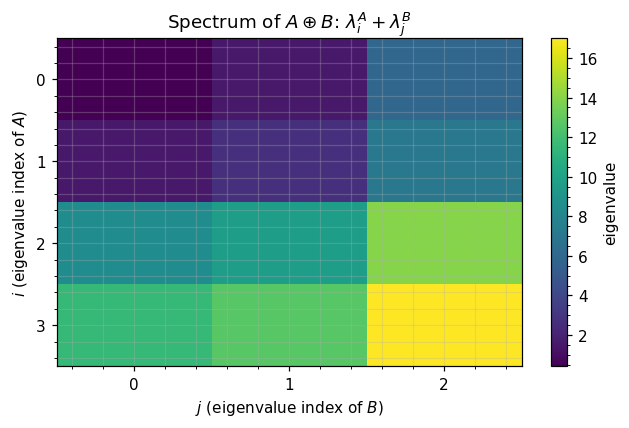

In [3]:
# Per-factor eigendecompositions
lambda_A, Q_A = jnp.linalg.eigh(A_mat)
lambda_B, Q_B = jnp.linalg.eigh(B_mat)

# Predicted spectrum: outer-sum of factor spectra
predicted = (lambda_A[:, None] + lambda_B[None, :]).flatten()
predicted = jnp.sort(predicted)

# Direct eigendecomposition of the dense KroneckerSum
direct = jnp.linalg.eigvalsh(KS_dense)
direct = jnp.sort(direct)

print(f"max eigenvalue mismatch : {jnp.max(jnp.abs(predicted - direct)):.2e}")
print(f"first 6 sum-eigs        : {predicted[:6]}")
print(f"first 6 direct eigs     : {direct[:6]}")

# Visualize spectrum as outer-sum heatmap
fig, ax = plt.subplots(figsize=(6, 4))
heat = lambda_A[:, None] + lambda_B[None, :]
im = ax.imshow(heat, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(lambda_B)))
ax.set_yticks(range(len(lambda_A)))
ax.set_xlabel(r"$j$ (eigenvalue index of $B$)")
ax.set_ylabel(r"$i$ (eigenvalue index of $A$)")
ax.set_title(r"Spectrum of $A\oplus B$: $\lambda^A_i + \lambda^B_j$")
plt.colorbar(im, ax=ax, label="eigenvalue")
plt.tight_layout()
plt.show()

## 3. KroneckerSum solve in $O(n_a^3 + n_b^3)$

Per eq. {eq}`eq:kron-sum-solve-logdet`, the solve is three steps:

1. Project $b$ into the joint eigenbasis: $\tilde b = (Q_A\otimes Q_B)^\top b$.
2. Element-wise divide by $\lambda^A_i + \lambda^B_j$.
3. Project back: $x = (Q_A\otimes Q_B)\,\tilde x$.

Steps 1 and 3 are Kronecker-matvecs at $O(n_a n_b(n_a+n_b))$. Step 2 is element-wise. The dominant cost is the two factor eigh calls.

This is the same scaling as a Kronecker product solve — additive separation costs no more than multiplicative.

In [4]:
# Manual solve through the eigenbasis (mirrors what a structured solver would do)
def kron_sum_solve(A_mat, B_mat, b):
    la, QA = jnp.linalg.eigh(A_mat)
    lb, QB = jnp.linalg.eigh(B_mat)
    n_a, n_b = la.shape[0], lb.shape[0]
    # rotate b into joint eigenbasis: vec(QB^T X QA), where X = mat(b)
    X = einx.id("(a b) -> b a", b, a=n_a, b=n_b)
    X_rot = QB.T @ X @ QA
    # divide by sum of spectra
    denom = la[None, :] + lb[:, None]
    Y_rot = X_rot / denom
    # rotate back
    Y = QB @ Y_rot @ QA.T
    return einx.id("b a -> (a b)", Y)

b = jax.random.normal(jax.random.PRNGKey(3), (12,))
x_struct = kron_sum_solve(A_mat, B_mat, b)
x_dense  = jnp.linalg.solve(KS_dense, b)
print(f"solve error : {jnp.linalg.norm(x_struct - x_dense):.2e}")

# logdet via the spectrum (one log-sum, no Cholesky)
logdet_struct = jnp.sum(jnp.log(lambda_A[:, None] + lambda_B[None, :]))
logdet_dense  = jnp.linalg.slogdet(KS_dense)[1]
print(f"logdet error: {abs(logdet_struct - logdet_dense):.2e}")

solve error : 8.99e-15


logdet error: 7.11e-15


## 4. `SumKronecker` — superposition of two Kronecker products

A different beast. Now we have *two* Kronecker products and we add them:

```{math}
:label: eq:sum-kron-def
M = A_1\otimes B_1 \;+\; A_2\otimes B_2
```

The canonical case is multi-output GPs with correlated tasks: $K_{\mathrm{task}}\otimes K_{\mathrm{spatial}} + \sigma^2 I_{\mathrm{task}}\otimes I_{\mathrm{spatial}}$. Or signal-plus-noise on a tensor grid. Or any covariance where two distinct Kronecker layers superpose.

Matvec is the obvious sum of Kronecker matvecs — cost $2 \cdot O(n_a n_b (n_a+n_b))$, twice that of a single Kronecker. Solve and logdet are the hard part: in general $A_1, A_2$ do not share eigenvectors, so we cannot simultaneously diagonalize and the spectrum is *not* a tidy sum or outer-product.

In [5]:
ks_keys = jax.random.split(jax.random.PRNGKey(10), 4)
A1 = psd_op(random_psd(ks_keys[0], 4))
B1 = psd_op(random_psd(ks_keys[1], 3))
A2 = psd_op(random_psd(ks_keys[2], 4))
B2 = psd_op(random_psd(ks_keys[3], 3))

SK = SumKronecker(Kronecker(A1, B1), Kronecker(A2, B2))
SK_dense = jnp.kron(A1.as_matrix(), B1.as_matrix()) + jnp.kron(A2.as_matrix(), B2.as_matrix())

v = jax.random.normal(jax.random.PRNGKey(11), (12,))
print(f"matvec error : {jnp.linalg.norm(SK.mv(v) - SK_dense @ v):.2e}")

# Are A1 and A2 jointly diagonalizable? Compute their commutator.
A1m, A2m = A1.as_matrix(), A2.as_matrix()
comm = A1m @ A2m - A2m @ A1m
print(f"||[A1, A2]||  : {jnp.linalg.norm(comm):.4f}  (non-zero → no shared eigenbasis)")

matvec error : 3.02e-14
||[A1, A2]||  : 35.6242  (non-zero → no shared eigenbasis)


## 5. The joint-eigenbasis-of-pair-2 trick

`gaussx`'s `SumKronecker.eigendecompose()` uses a hybrid approach:

1. Eigendecompose the *second* pair: $A_2 = Q_C \Lambda_C Q_C^\top$, $B_2 = Q_D \Lambda_D Q_D^\top$. Cost: $O(n_a^3 + n_b^3)$.
2. Rotate the *first* pair into that basis: $\tilde A_1 = Q_C^\top A_1 Q_C$, $\tilde B_1 = Q_D^\top B_1 Q_D$. Cost: $O(n_a^3 + n_b^3)$.
3. Form the rotated full matrix $\tilde A_1 \otimes \tilde B_1 + \mathrm{diag}(\lambda^C_i \lambda^D_j)$ — an $n_a n_b\times n_a n_b$ matrix — and call `eigh`. **Cost: $O((n_a n_b)^3)$.**

The third step is the bottleneck. Unlike `KroneckerSum`, we cannot avoid a dense pass on the full $N=n_a n_b$ matrix. The trick only buys us:

- A *symmetric* form for `eigh` (the rotation makes $A_2\otimes B_2$ purely diagonal so the second pair contributes only to the diagonal).
- Cheaper structural inheritance (the eigendecomposition is computed once and reused for solve, logdet, and matrix square root).

`SumKronecker` is intended for **moderate factor sizes** — typical multi-output GPs with task dimension $\leq 10$. Past that, you need iterative Krylov solvers (1.D) or alternative parameterizations.

In [6]:
# Verify gaussx's SumKronecker.eigendecompose
evals, Q = SK.eigendecompose()
recon = Q @ jnp.diag(evals) @ Q.T
print(f"eigendecomp residual : {jnp.linalg.norm(recon - SK_dense):.2e}")
print(f"logdet via eigs      : {float(jnp.sum(jnp.log(evals))):.6f}")
print(f"logdet ref           : {float(jnp.linalg.slogdet(SK_dense)[1]):.6f}")

# Solve through the eigendecomposition
b = jax.random.normal(jax.random.PRNGKey(12), (12,))
x_eig = Q @ ((Q.T @ b) / evals)
x_ref = jnp.linalg.solve(SK_dense, b)
print(f"solve error via eigs : {jnp.linalg.norm(x_eig - x_ref):.2e}")

eigendecomp residual : 1.07e-13
logdet via eigs      : 27.528890
logdet ref           : 27.528890
solve error via eigs : 1.97e-14


## 6. Cost & structure comparison

Side-by-side, with $N = n_a n_b$:

| Aspect | `Kronecker` $A\otimes B$ | `KroneckerSum` $A\oplus B$ | `SumKronecker` $A_1\otimes B_1 + A_2\otimes B_2$ |
|---|---|---|---|
| Storage | $n_a^2 + n_b^2$ | $n_a^2 + n_b^2$ | $2(n_a^2 + n_b^2)$ |
| Matvec | $O(N(n_a + n_b))$ | $O(N(n_a + n_b))$ | $2\cdot O(N(n_a + n_b))$ |
| Spectrum | $\lambda^A_i \lambda^B_j$ | $\lambda^A_i + \lambda^B_j$ | no closed form |
| Solve / logdet | $O(n_a^3 + n_b^3)$ | $O(n_a^3 + n_b^3)$ | $O(N^3)$ via eigh on $\tilde A_1\otimes\tilde B_1 + \mathrm{diag}$ |
| Constructor | `Kronecker(A, B)` | `KroneckerSum(A, B)` | `SumKronecker(Kronecker(A1,B1), Kronecker(A2,B2))` |

The two takeaways:

1. **`KroneckerSum` is essentially free** — same asymptotic cost as a single Kronecker product, including a clean closed-form spectrum.
2. **`SumKronecker` is moderate-only** — the cubic-in-$N$ inner eigh is the price of not having a shared eigenbasis. Use it when $N \lesssim$ a few thousand (multi-output GP with small task dimension); reach for iterative methods otherwise.

## 7. Solve cost: KroneckerSum vs SumKronecker

Theoretical FLOP curves for the eigendecomposition-based solve, sweeping $N = n^2$ (square layout $n_a = n_b = n$). `KroneckerSum` scales as $O(n^3) = O(N^{3/2})$; `SumKronecker` as $O(N^3)$. Plot is log–log so the slopes are exactly the asymptotic exponents.

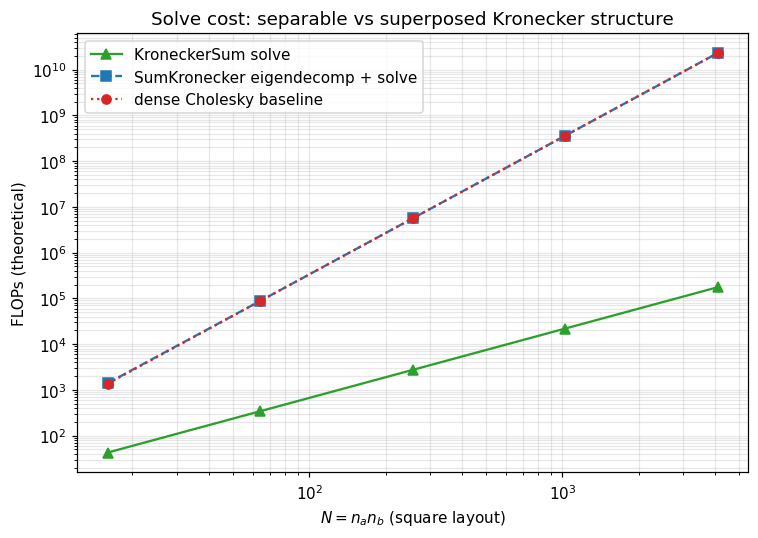

In [7]:
ns = np.array([4, 8, 16, 32, 64])
Ns = ns**2

kron_sum_solve_flops    = 2 * (1/3) * ns**3                      # two eigh calls of size n
sum_kron_eig_flops       = 2 * (1/3) * ns**3 + (1/3) * Ns**3     # two factor eighs + dense (n^2)^3 eigh
dense_solve_flops        = (1/3) * Ns**3                          # full Cholesky on N=n^2

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(Ns, kron_sum_solve_flops, "C2-",  marker="^", label="KroneckerSum solve")
ax.loglog(Ns, sum_kron_eig_flops,   "C0--", marker="s", label="SumKronecker eigendecomp + solve")
ax.loglog(Ns, dense_solve_flops,    "C3:",  marker="o", label="dense Cholesky baseline")
ax.set_xlabel(r"$N = n_a n_b$ (square layout)")
ax.set_ylabel("FLOPs (theoretical)")
ax.set_title("Solve cost: separable vs superposed Kronecker structure")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 8. Which one do I want?

A simple decision rule when you build a covariance with Kronecker-shaped pieces:

| Pattern in your covariance | Reach for |
|---|---|
| "$A$ acts on rows, $B$ acts on columns, contributions add" (separable PDE / GMRF) | `KroneckerSum(A, B)` |
| "Kernel on a tensor grid times a coregionalization matrix" | `Kronecker(K_task, K_space)` |
| "Kernel times correlation **plus** iid noise on a tensor grid" | `SumKronecker(Kronecker(K_task, K_space), σ²·Kronecker(I, I))` |
| "Two independent Kronecker layers superposed" (multi-output, multi-fidelity) | `SumKronecker(...)` |
| "Three or more Kronecker layers" | iterative methods — see 1.E (SLQ logdet, BBMM) |

The naming is admittedly cruel — "Kronecker sum" means *$A\otimes I + I\otimes B$* in linear-algebra texts, but a "sum of Kroneckers" reads like the same thing in plain English. In `gaussx`, the operator names track the linear-algebra convention: `KroneckerSum = ` $A\oplus B$, `SumKronecker = ` $\sum_k A_k\otimes B_k$. When in doubt, check the eigendecomposition: if the spectrum is a tidy outer-sum of two factor spectra, you have a `KroneckerSum`. If not, you have a `SumKronecker`.

The rest of Part 1 fills in the remaining structured leaves (`Toeplitz`, `BlockTriDiag`, `MaskedOperator`) and then 1.7 explains how the `kronecker_sum_tag` attached on construction lets `gaussx`'s primitives dispatch through any of these forms automatically.